In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Load and preview datasets
walmart = pd.read_csv('../dataset/Walmart.csv')
fedfunds = pd.read_csv('../dataset/FEDFUNDS.csv')
cci = pd.read_excel('../dataset/ConsumerConfidenceIndex.xls')

print(walmart.head())
print(fedfunds.head())
print(cci.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
  observation_date  FEDFUNDS
0       1954-07-01      0.80
1       1954-08-01      1.22
2       1954-09-01      1.07
3       1954-10-01      0.85
4       1954-11-01      0.83
      Month  Year   ICS  Cases
0  November  1952  86.2   1714
1  February  1953  90.7   3097
2    August  1953  80.8   1022
3  November  1953  80.7   1023
4  February  1954  82.0   30

In [3]:
# Walmart: ensure datetime format
walmart['Date'] = pd.to_datetime(walmart['Date'], format='%d-%m-%Y')

# FEDFUNDS: ensure datetime format
fedfunds['observation_date'] = pd.to_datetime(fedfunds['observation_date'], infer_datetime_format=True, errors='coerce')
fedfunds.rename(columns={'observation_date': 'Date', 'FEDFUNDS': 'FedFunds'}, inplace=True)

# ConsumerConfidenceIndex: Create a proper datetime column
cci['Date'] = pd.to_datetime(cci['Month'] + ' ' + cci['Year'].astype(str), format='%B %Y')

# Align ConsumerConfidenceIndex columns with Fridays in Walmart data
walmart = walmart.sort_values(by='Date')
fedfunds = fedfunds.sort_values(by='Date')
cci = cci.sort_values(by='Date')

# Joining dataframes
df = pd.merge_asof(walmart, fedfunds, on='Date', direction='backward')
df = pd.merge_asof(df, cci[['Date', 'ICS']], on='Date', direction='backward')

# Inspect the combined data frame
print(df)

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1 2010-02-05    1643690.90             0        42.31       2.572   
1        10 2010-02-05    2193048.75             0        54.34       2.962   
2        37 2010-02-05     536006.73             0        45.97       2.572   
3        17 2010-02-05     789036.02             0        23.11       2.666   
4        30 2010-02-05     465108.52             0        39.05       2.572   
...     ...        ...           ...           ...          ...         ...   
6430     25 2012-10-26     688940.94             0        56.69       3.882   
6431      5 2012-10-26     319550.77             0        71.70       3.506   
6432     40 2012-10-26     921264.52             0        49.65       3.917   
6433     18 2012-10-26    1127516.25             0        56.09       3.917   
6434     45 2012-10-26     760281.43             0        58.85       3.882   

             CPI  Unemployment  FedFunds   ICS  
0 

/tmp/ipykernel_9483/597301506.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  fedfunds['observation_date'] = pd.to_datetime(fedfunds['observation_date'], infer_datetime_format=True, errors='coerce')


In [4]:
# Reorder columns for clarity
df = df[['Store', 'Date', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 
         'CPI', 'Unemployment', 'FedFunds', 'ICS', 'Weekly_Sales']]

# Rename columns for clarity
df.columns = ['store_id', 'date', 'is_holiday', 'temperature', 
              'fuel_price', 'cpi', 'unemployment', 'fed_funds', 'ics', 'weekly_sales']

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store_id      6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   is_holiday    6435 non-null   int64         
 3   temperature   6435 non-null   float64       
 4   fuel_price    6435 non-null   float64       
 5   cpi           6435 non-null   float64       
 6   unemployment  6435 non-null   float64       
 7   fed_funds     6435 non-null   float64       
 8   ics           6435 non-null   float64       
 9   weekly_sales  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 502.9 KB
None


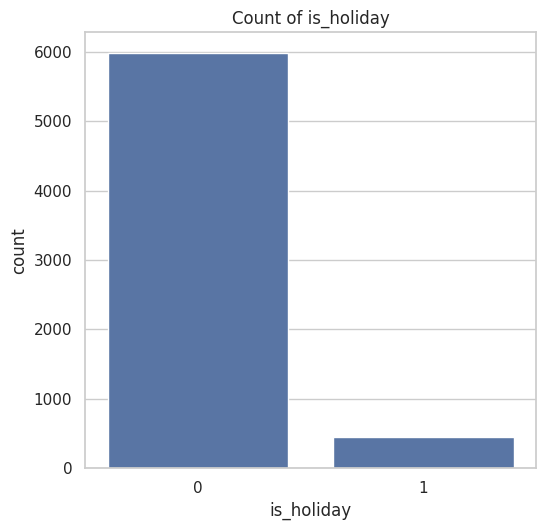

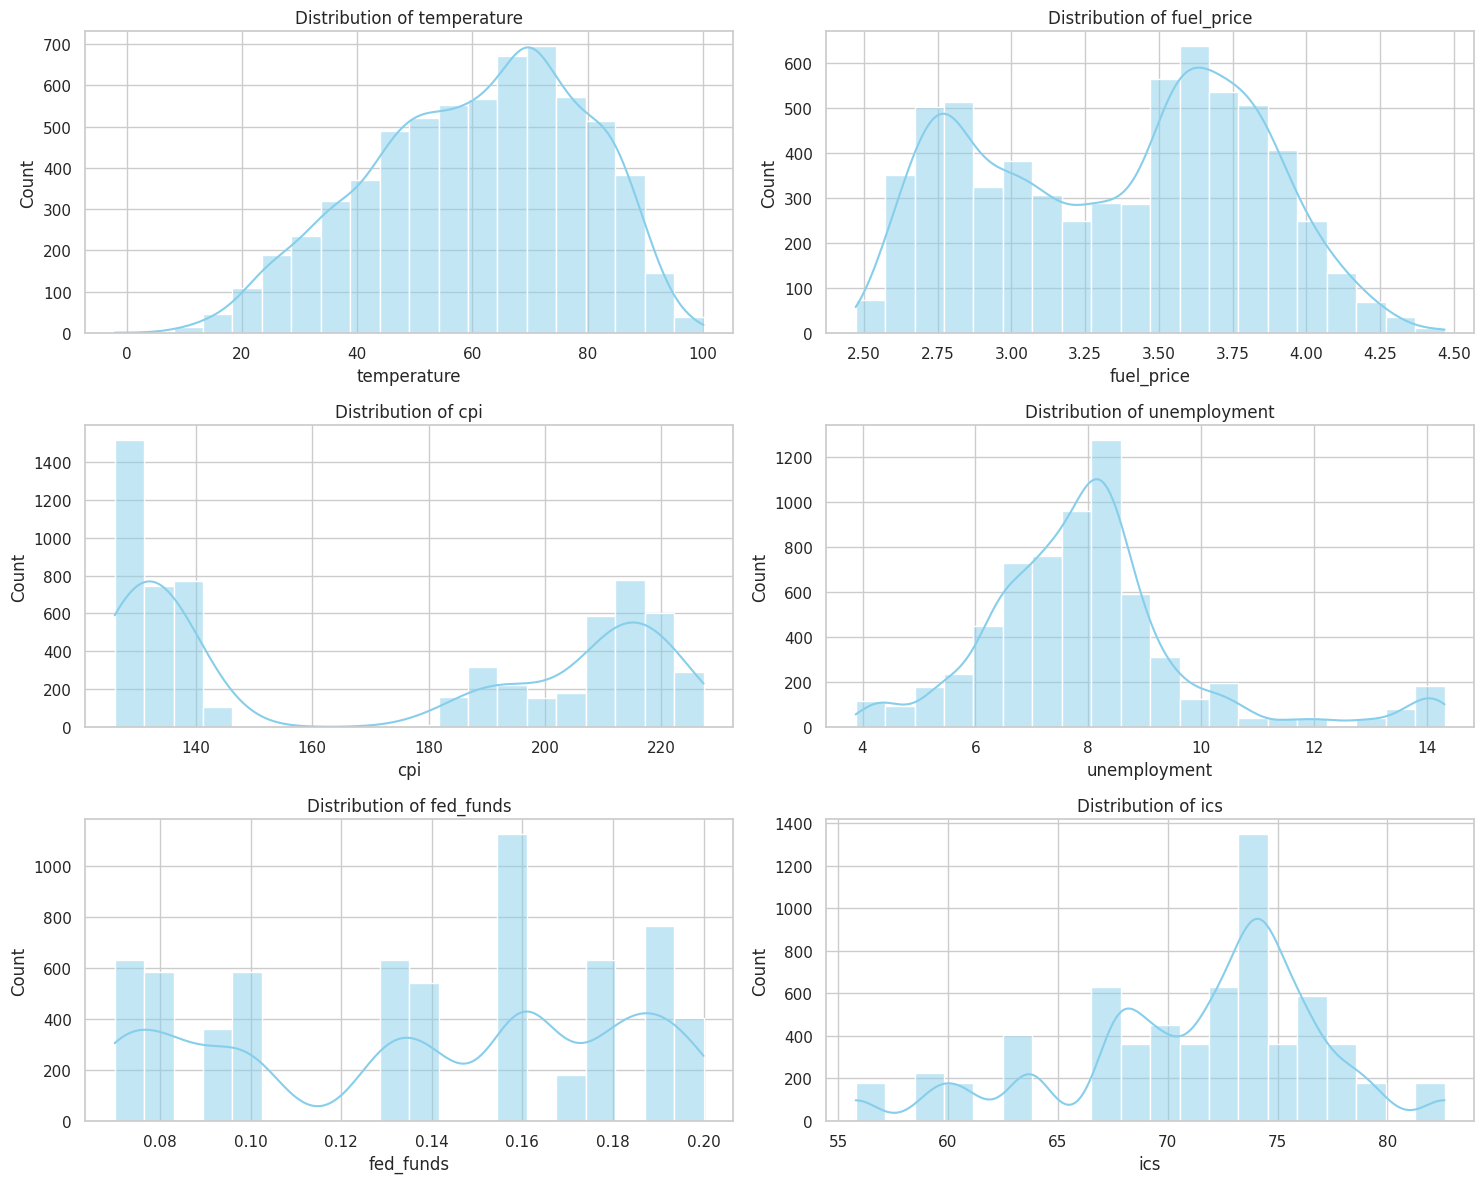

In [5]:
# Set the plot style
sns.set_theme(style="whitegrid")

# Categorical variables
categorical_features = ['is_holiday']

# Numerical variables
numerical_features = ['temperature', 'fuel_price', 'cpi', 'unemployment', 'fed_funds', 'ics']

# Distributions of categorical features (bar plots)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns of subplots
    sns.countplot(x=feature, data=df)
    plt.title(f'Count of {feature}')
    plt.tight_layout()

plt.show()

# Distributions of numerical features (histograms + KDE)
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)  # 3 rows, 2 columns of subplots
    sns.histplot(df[feature], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()

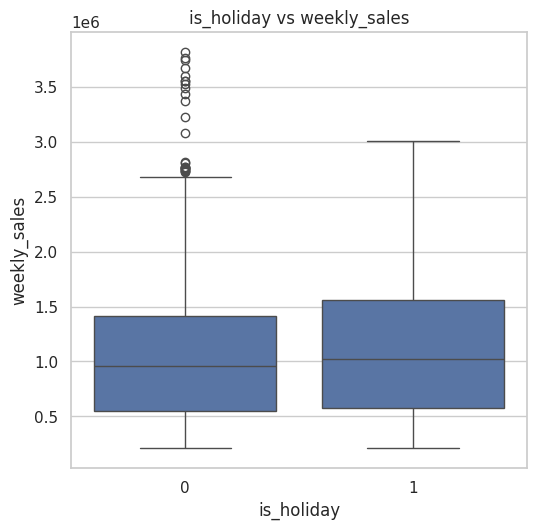

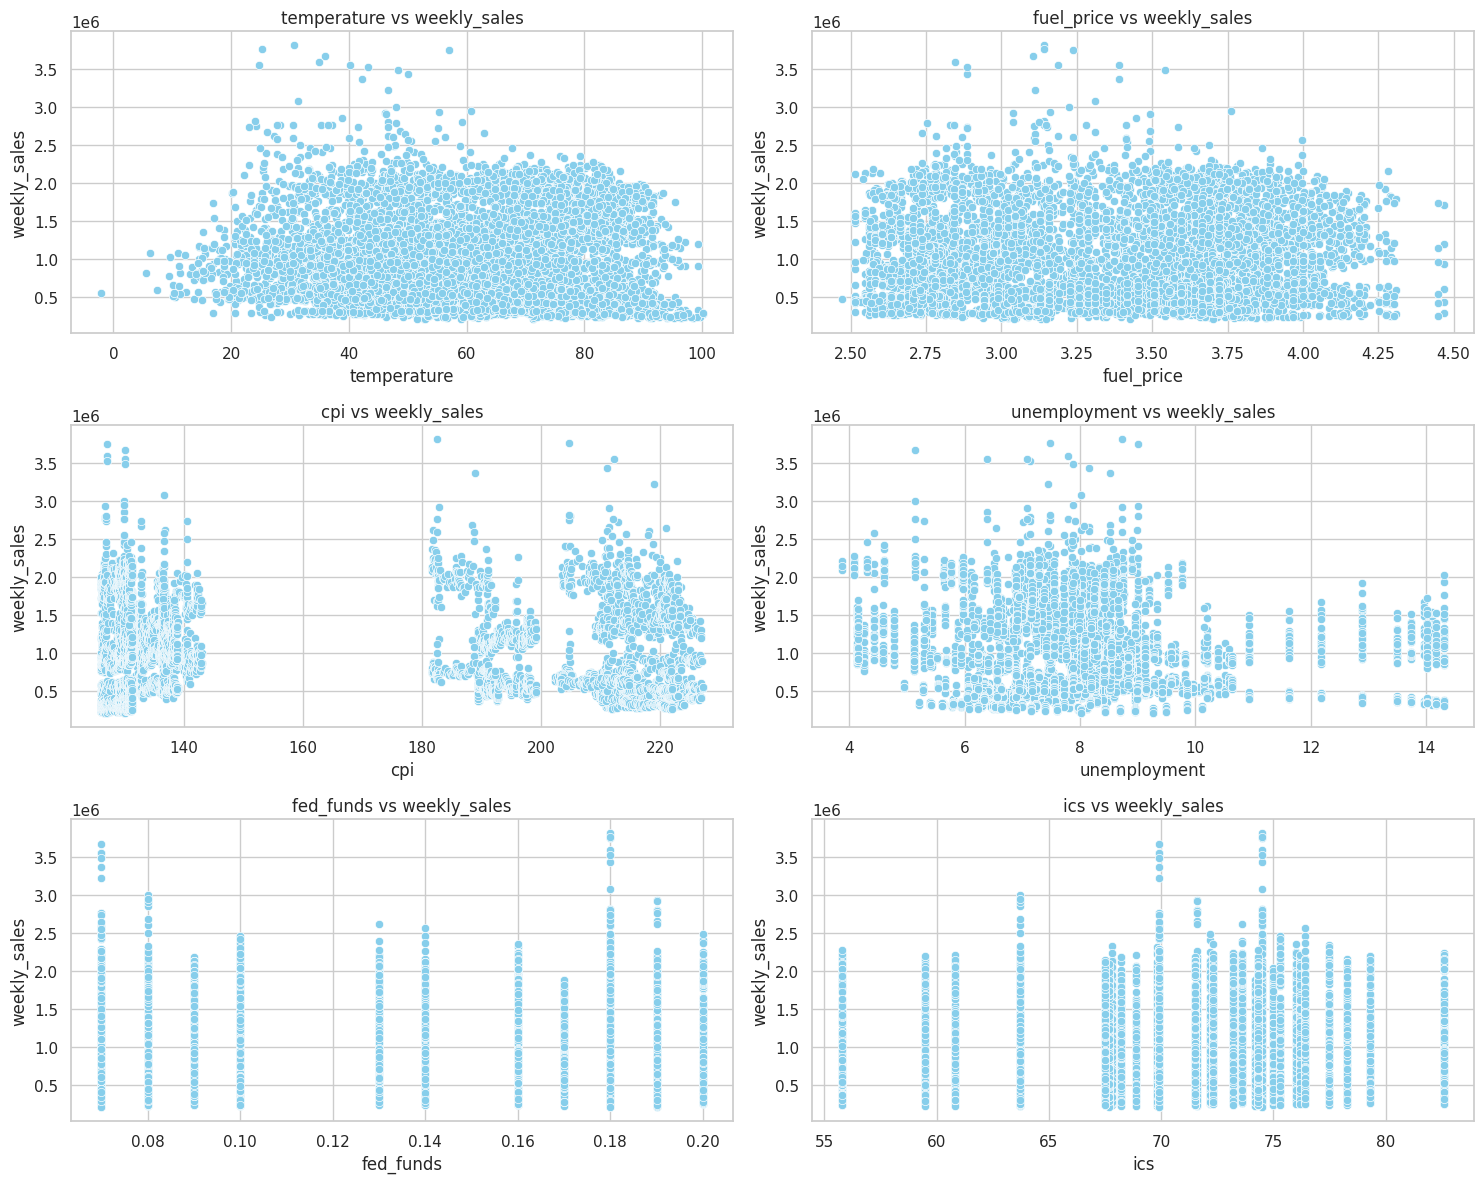

In [6]:
# Feature vs target: Box plots for categorical features vs 'weekly_sales'
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns of subplots
    sns.boxplot(x=feature, y='weekly_sales', data=df)
    plt.title(f'{feature} vs weekly_sales')
    plt.tight_layout()

plt.show()

# 4. Feature vs target: Scatter plots for numerical features vs 'weekly_sales'
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)  # 3 rows, 2 columns of subplots
    sns.scatterplot(x=df[feature], y=df['weekly_sales'], color='skyblue')
    plt.title(f'{feature} vs weekly_sales')
    plt.tight_layout()

plt.show()

Levene's Test p-values:
is_holiday: p-value = 0.0012

Breusch-Pagan Test p-values:
temperature: p-value = 0.3039
fuel_price: p-value = 0.0030
cpi: p-value = 0.6647
unemployment: p-value = 0.0000
fed_funds: p-value = 0.2813
ics: p-value = 0.7306

Variance is not constant, applying Box-Cox transformation on 'weekly_sales'.
Box-Cox applied with lambda: 0.2713


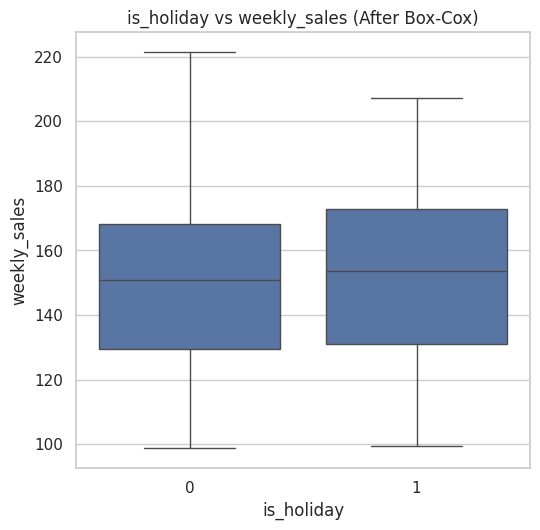

In [7]:
# Step 1: Define features
categorical_features = ['is_holiday']
numerical_features = ['temperature', 'fuel_price', 'cpi', 'unemployment', 'fed_funds', 'ics']

# Collect p-values from Levene's test for each categorical feature
levene_p_values = {}
# Collect p-values from Breusch-Pagan test for each numerical feature
bp_p_values = {}

alpha = 0.05

# Perform Levene's Test for categorical features
for feature in categorical_features:
    groups = [df[df[feature] == cat]['weekly_sales'] for cat in df[feature].unique()]
    stat, p_value = stats.levene(*groups)
    levene_p_values[feature] = p_value

# Perform Breusch-Pagan Test for numerical features
for feature in numerical_features:
    # Perform a regression for the Breusch-Pagan test
    model = smf.ols(f'weekly_sales ~ {feature}', data=df).fit()
    residuals = model.resid
    exog = sm.add_constant(df[feature])  # Add constant term for the test
    _, p_value, _, _ = sm.stats.diagnostic.het_breuschpagan(residuals, exog)
    bp_p_values[feature] = p_value

# Step 2: Print p-values for Levene's Test and Breusch-Pagan Test
print("Levene's Test p-values:")
for feature, p_value in levene_p_values.items():
    print(f"{feature}: p-value = {p_value:.4f}")

print("\nBreusch-Pagan Test p-values:")
for feature, p_value in bp_p_values.items():
    print(f"{feature}: p-value = {p_value:.4f}")

# Step 3: Check if any p-value is less than alpha (0.05)
# If any p-value is significant, apply Box-Cox transformation
apply_boxcox = False
for p_value in levene_p_values.values():
    if p_value < alpha:
        apply_boxcox = True
        break

for p_value in bp_p_values.values():
    if p_value < alpha:
        apply_boxcox = True
        break

# Step 4: Apply Box-Cox transformation if necessary
if apply_boxcox:
    print("\nVariance is not constant, applying Box-Cox transformation on 'weekly_sales'.")
    # Box-Cox transformation (only works for positive values)
    df['weekly_sales'], lambda_value = stats.boxcox(df['weekly_sales'] + 1)  # Adding 1 to avoid log(0)
    print(f"Box-Cox applied with lambda: {lambda_value:.4f}")

# Step 5: Visualize the variance (before and after Box-Cox transformation)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns of subplots
    sns.boxplot(x=feature, y='weekly_sales', data=df)
    plt.title(f'{feature} vs weekly_sales (After Box-Cox)')
    plt.tight_layout()

plt.show()

# Step 6: Save the transformed dataset
df.to_csv("../dataset/preprocessed_dataset.csv", index=False)

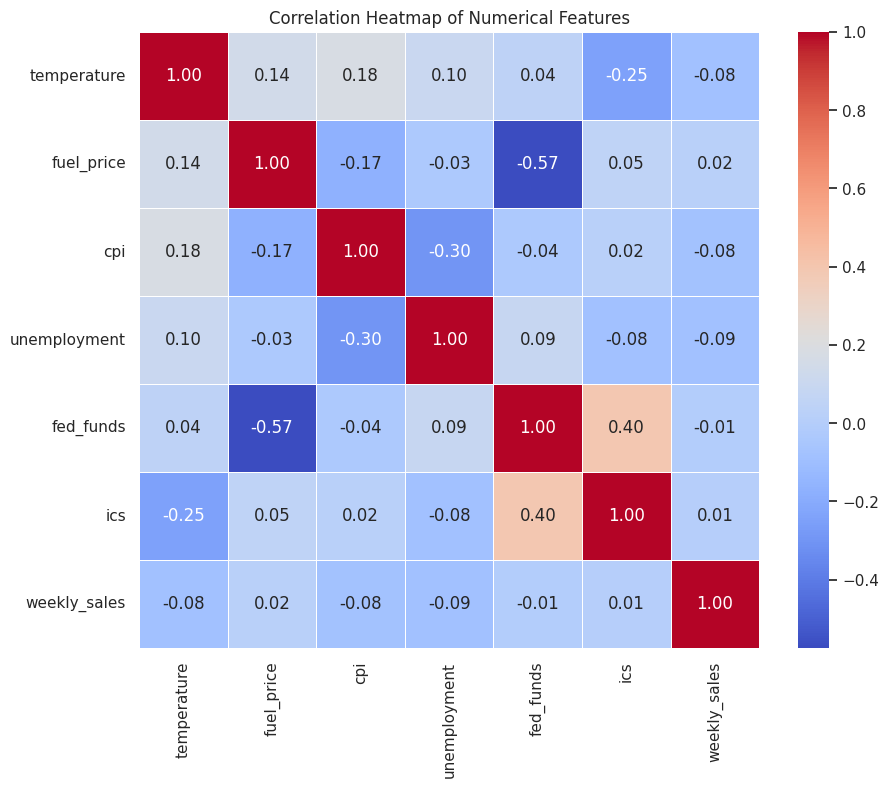

In [8]:
# Correlation Heatmap for numerical features
correlation_matrix = df[numerical_features + ['weekly_sales']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()